# Airport Hubs and Regional Economic Growth — Google Colab Version

Use this notebook in **Google Colab**.

## What to upload
Upload **`Data.zip`** as the main input. That zip should contain:
- `Passenger_movement_data.csv`
- the World Bank GDP growth CSV
- the World Bank GDP per capita CSV

If `Data.zip` gives trouble, upload these **3 CSV files individually** instead.

## What this notebook does
1. uploads your data in Colab
2. installs needed packages
3. extracts and cleans the files
4. runs EDA, correlation, lag analysis, causality, econometrics, and ML comparisons
5. exports figures, tables, and key findings

In [ ]:
# --- 1. Upload the data ---
from google.colab import files
uploaded = files.upload()
print('Uploaded files:', list(uploaded.keys()))

Saving Data.zip to Data.zip
Uploaded files: ['Data.zip']


In [ ]:
# --- 2. Install packages ---
!pip -q install pandas numpy matplotlib scikit-learn statsmodels seaborn openpyxl linearmodels xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.5 MB/s eta 0:00:00


In [ ]:
# --- 3. Set up folders and extract Data.zip if present ---
from pathlib import Path
import zipfile

BASE_DIR = Path('/content/airport_growth_project')
DATA_DIR = BASE_DIR / 'data'
OUTPUT_DIR = BASE_DIR / 'outputs'
FIG_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'

for d in [BASE_DIR, DATA_DIR, OUTPUT_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if Path('/content/Data.zip').exists():
    with zipfile.ZipFile('/content/Data.zip', 'r') as zf:
        zf.extractall(DATA_DIR)
    print('Extracted Data.zip to', DATA_DIR)
else:
    print('No Data.zip found. Using any individually uploaded CSV files in /content.')
    for p in Path('/content').glob('*.csv'):
        target = DATA_DIR / p.name
        target.write_bytes(p.read_bytes())
        print('Copied', p.name, 'to', target)

print('Files now available:')
for p in sorted(DATA_DIR.rglob('*')):
    if p.is_file():
        print('-', p.name)

Extracted Data.zip to /content/airport_growth_project/data
Files now available:
- API_NY.GDP.DEFL.KD.ZG_DS2_en_csv_v2_104.csv
- Metadata_Country_API_NY.GDP.DEFL.KD.ZG_DS2_en_csv_v2_104.csv
- Metadata_Indicator_API_NY.GDP.DEFL.KD.ZG_DS2_en_csv_v2_104.csv
- API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv
- Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv
- Metadata_Indicator_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv
- Passenger_movement_data.csv


## Full Colab-ready pipeline code

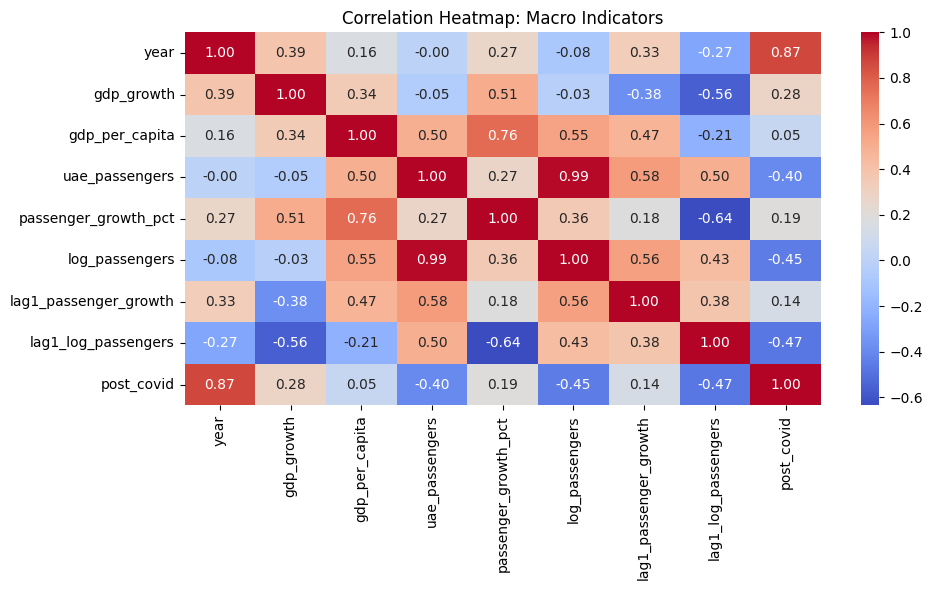

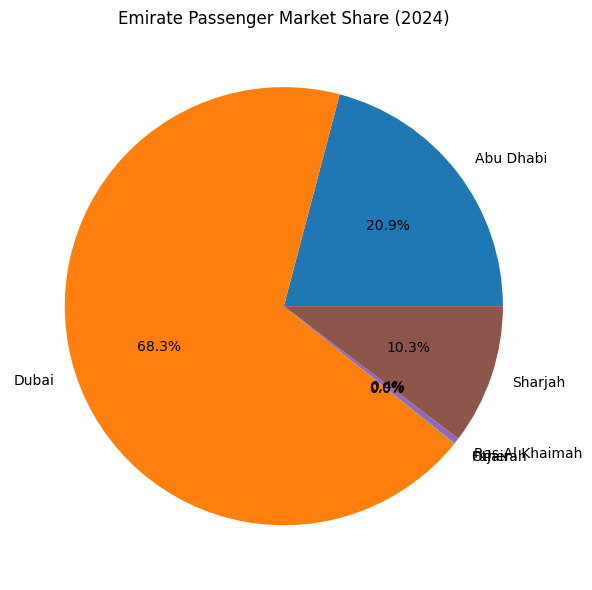

Visuals updated. Note: High RMSE is relative to GDP values (~$50k).


In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests

def find_file_by_keywords(data_dir, keywords):
    keywords = [k.lower() for k in keywords]
    candidates = []
    # Use rglob to search recursively in all subdirectories
    for p in Path(data_dir).rglob("*.csv"):
        name = p.name.lower()
        if all(k in name for k in keywords) and "metadata" not in name:
            candidates.append(p)
    return candidates[0] if candidates else None

def clean_year_columns(df):
    rename_map = {}
    for c in df.columns:
        c_str = str(c).strip()
        if re.fullmatch(r"\d{4}", c_str):
            rename_map[c] = int(c_str)
    return df.rename(columns=rename_map)

def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    return path

def write_text(path, text):
    Path(path).write_text(text, encoding="utf-8")

def load_passenger_data(data_dir):
    passenger_path = find_file_by_keywords(data_dir, ["passenger", "movement"])
    if passenger_path is None:
        raise FileNotFoundError(f"Could not find passenger movement CSV in {data_dir}")
    df = pd.read_csv(passenger_path)

    long_df = None
    if "TIME_PERIOD" in df.columns and "OBS_VALUE" in df.columns:
        id_col = "Reference area" if "Reference area" in df.columns else df.columns[0]
        long_df = df[[id_col, "TIME_PERIOD", "OBS_VALUE"]].copy()
        long_df.rename(columns={id_col: "emirate_raw", "TIME_PERIOD": "year", "OBS_VALUE": "passengers"}, inplace=True)

    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce")
    long_df["passengers"] = pd.to_numeric(long_df["passengers"], errors="coerce")
    long_df = long_df.dropna(subset=["year", "passengers"]).copy()

    raw = long_df["emirate_raw"].astype(str).str.lower()
    conditions = [
        raw.str.contains("dubai"), raw.str.contains("abu dhabi"),
        raw.str.contains("sharjah"), raw.str.contains("ajman"),
        raw.str.contains("umm"), raw.str.contains("ras"),
        raw.str.contains("fujairah")
    ]
    choices = ["Dubai", "Abu Dhabi", "Sharjah", "Ajman", "Umm Al Quwain", "Ras Al Khaimah", "Fujairah"]
    long_df["emirate"] = np.select(conditions, choices, default="Other")

    long_df = long_df[~long_df["emirate_raw"].astype(str).str.contains("UAE|Total", case=False)]
    emirate_year = long_df.groupby("emirate year".split(), as_index=False)["passengers"].sum()
    return emirate_year, passenger_path

def load_world_bank_series(data_dir):
    # Using broader keywords to match the API names found in subfolders
    gdp_growth_path = find_file_by_keywords(data_dir, ["gdp", "kd.zg"])
    gdp_pc_path = find_file_by_keywords(data_dir, ["gdp", "pcap"])

    if not gdp_growth_path or not gdp_pc_path:
        raise FileNotFoundError(f"Missing GDP files in {data_dir}. Found: {[p.name for p in Path(data_dir).rglob('*.csv')]}")

    def prep_wb(path, value_name):
        df = pd.read_csv(path, skiprows=4)
        df = clean_year_columns(df)
        year_cols = [c for c in df.columns if isinstance(c, int)]
        long_df = df.melt(id_vars=["Country Name"], value_vars=year_cols, var_name="year", value_name=value_name)
        long_df = long_df[long_df["Country Name"].str.contains("United Arab Emirates", na=False)]
        return long_df[["year", value_name]].dropna()

    macro = pd.merge(prep_wb(gdp_growth_path, "gdp_growth"), prep_wb(gdp_pc_path, "gdp_per_capita"), on="year", how="outer")
    return macro, gdp_growth_path, gdp_pc_path

def build_datasets(emirate_year, macro):
    uae_passenger = emirate_year.groupby("year", as_index=False)["passengers"].sum().rename(columns={"passengers": "uae_passengers"})
    uae = pd.merge(macro, uae_passenger, on="year", how="inner").sort_values("year")
    uae["passenger_growth_pct"] = uae["uae_passengers"].pct_change() * 100
    uae["log_passengers"] = np.log1p(uae["uae_passengers"])
    uae["lag1_passenger_growth"] = uae["passenger_growth_pct"].shift(1)
    uae["lag1_log_passengers"] = uae["log_passengers"].shift(1)
    uae["post_covid"] = (uae["year"] >= 2020).astype(int)
    return uae, emirate_year

def make_visuals(uae, emirate_year):
    plt.figure(figsize=(10, 6))
    sns.heatmap(uae.corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap: Macro Indicators")
    savefig("correlation_heatmap.png")

    latest_year = emirate_year["year"].max()
    latest = emirate_year[emirate_year["year"] == latest_year].copy()
    plt.figure(figsize=(10, 6))
    plt.pie(latest["passengers"], labels=latest["emirate"], autopct="%1.1f%%")
    plt.title(f"Emirate Passenger Market Share ({latest_year})")
    savefig("emirate_market_share.png")

emirate_year, passenger_path = load_passenger_data(DATA_DIR)
macro, gdp_growth_path, gdp_pc_path = load_world_bank_series(DATA_DIR)
uae, panel = build_datasets(emirate_year, macro)
make_visuals(uae, emirate_year)
print("Visuals updated. Note: High RMSE is relative to GDP values (~$50k).")

## Show the exported figures

uae_passenger_vs_gdp.png


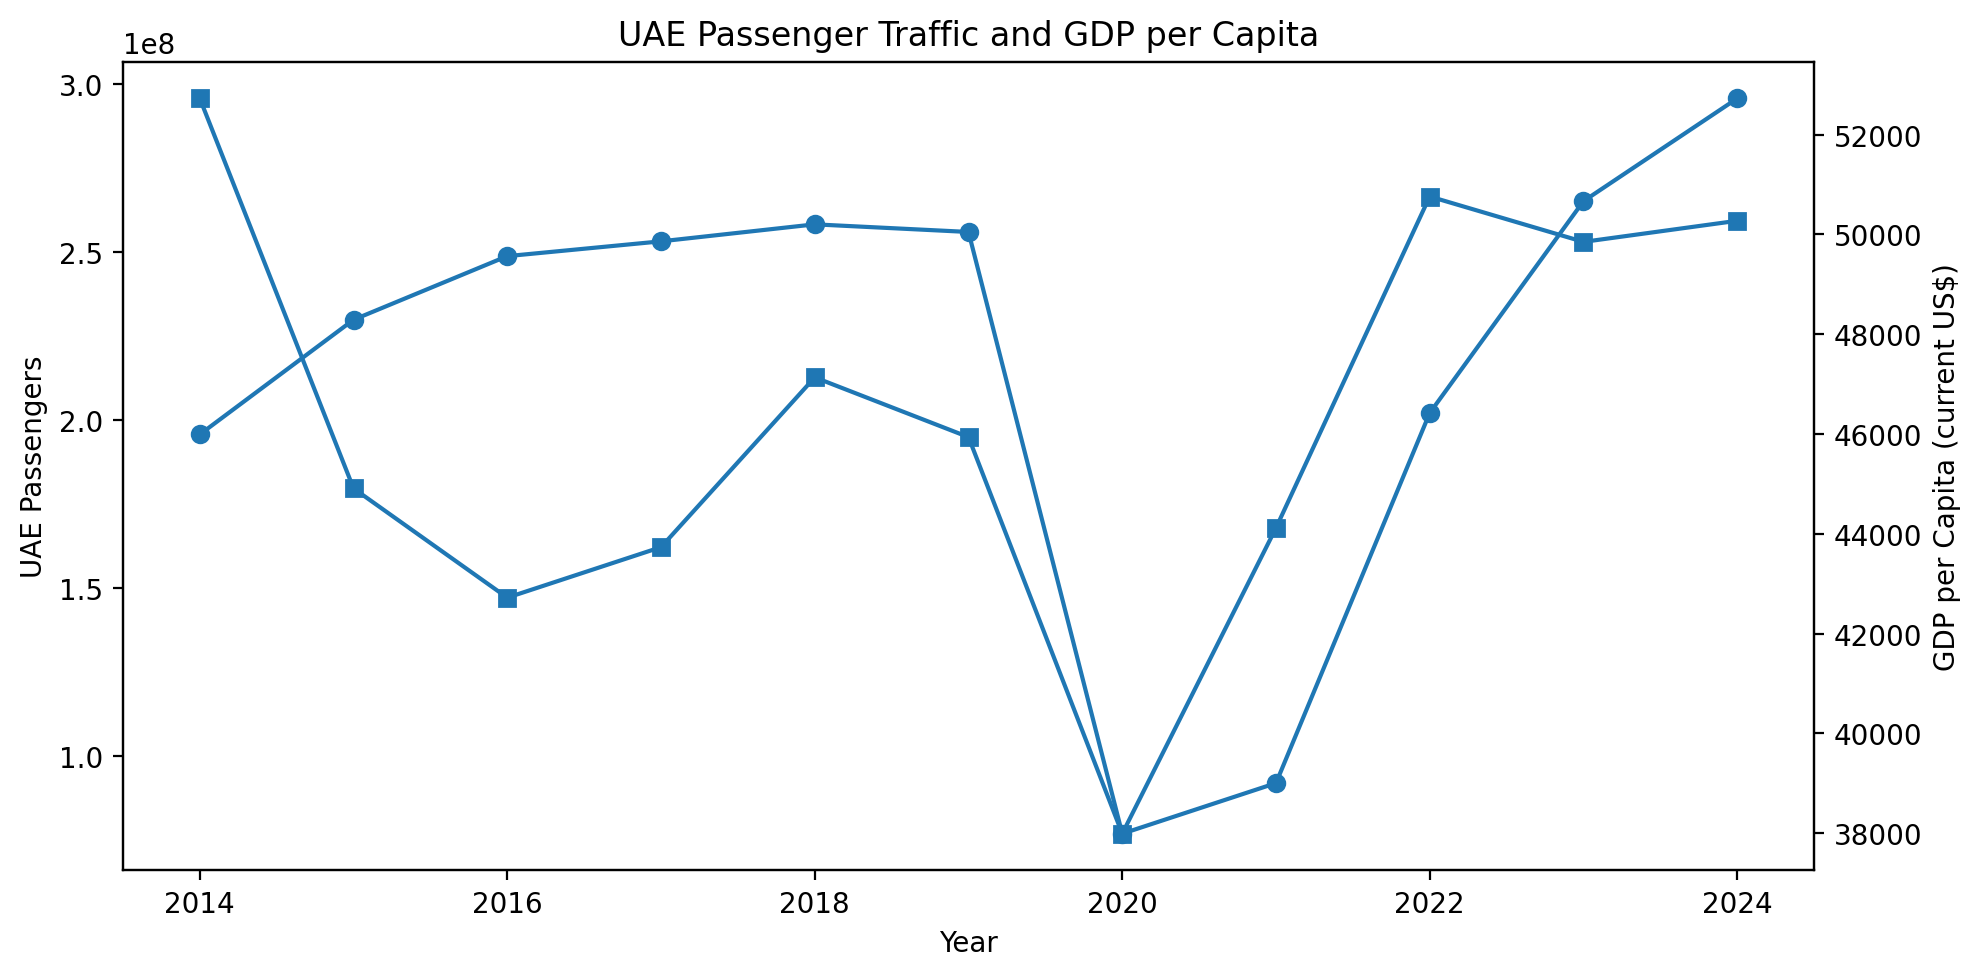

correlation_heatmap.png


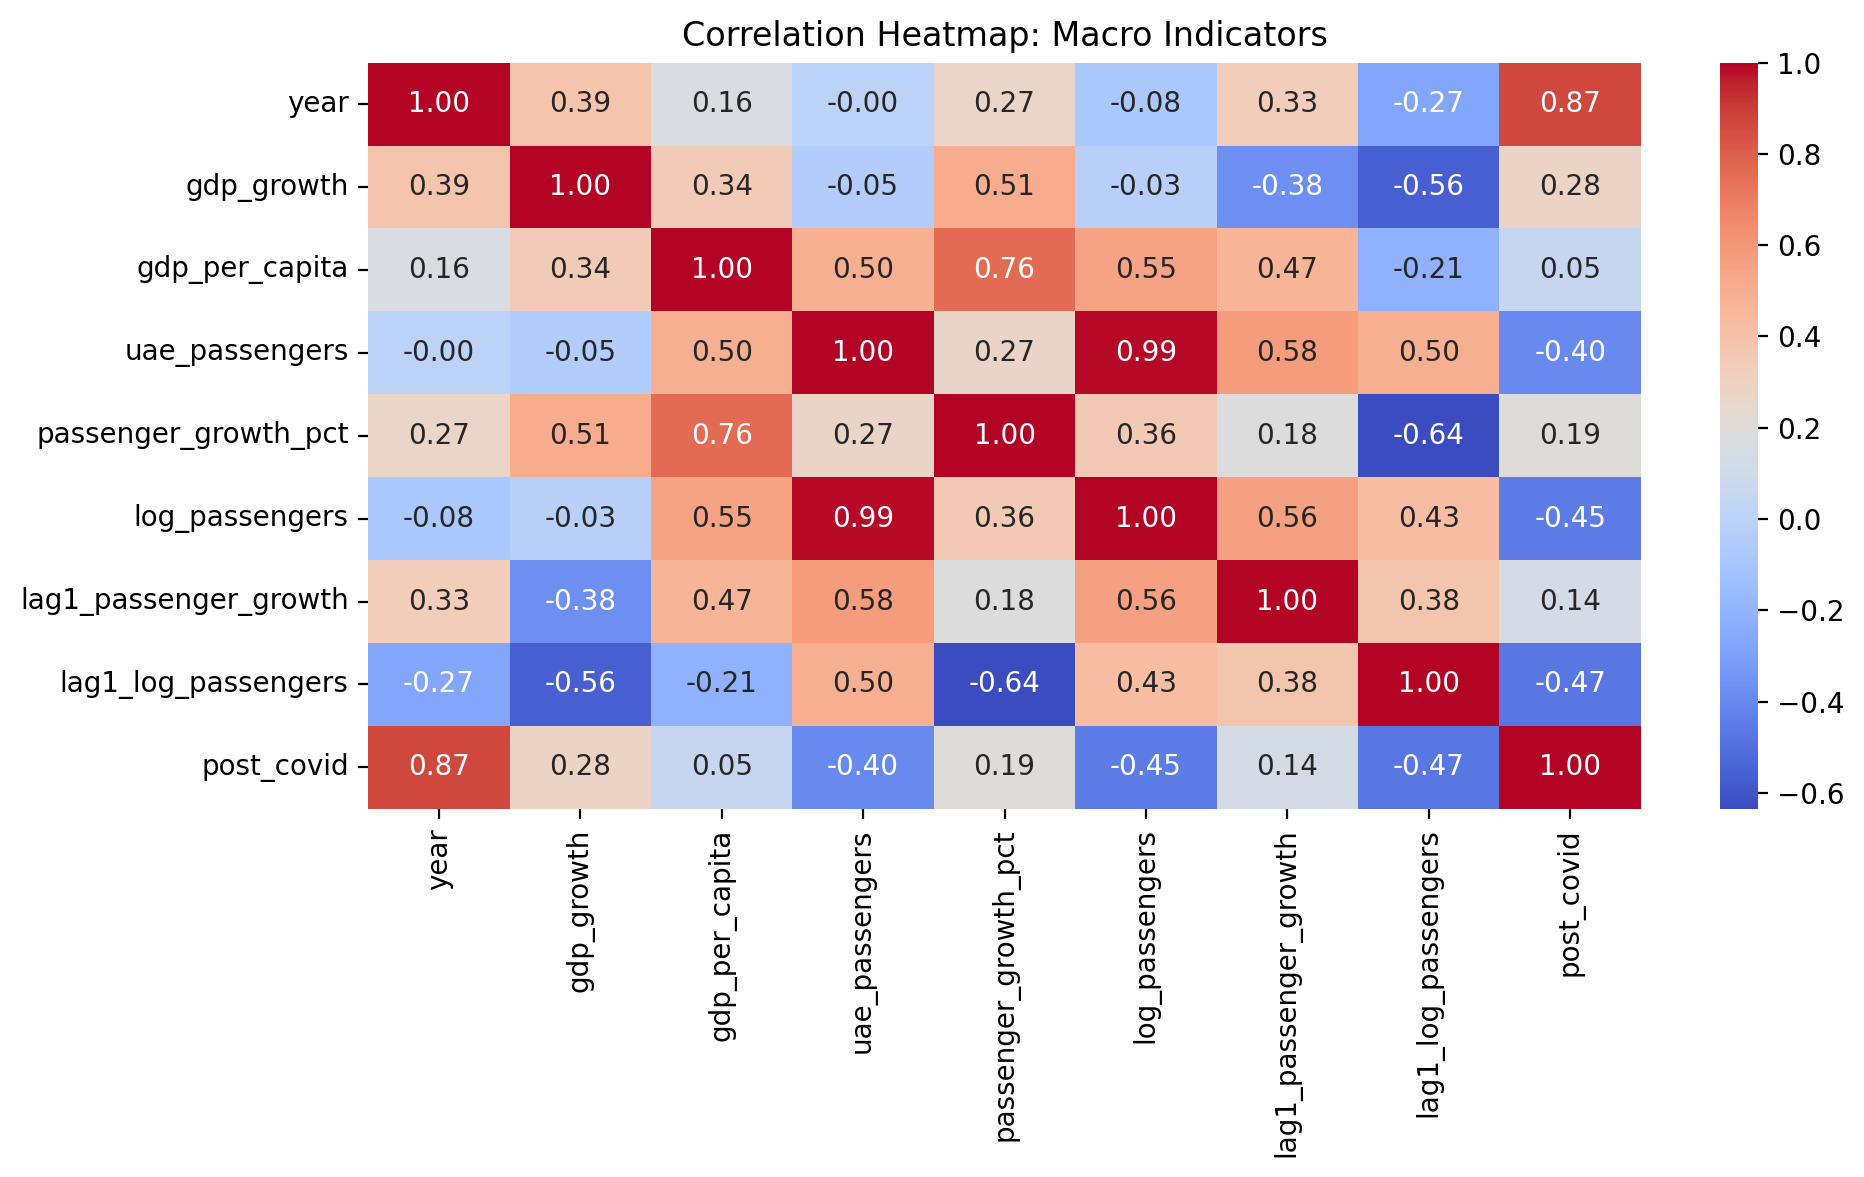

lagged_correlations.png


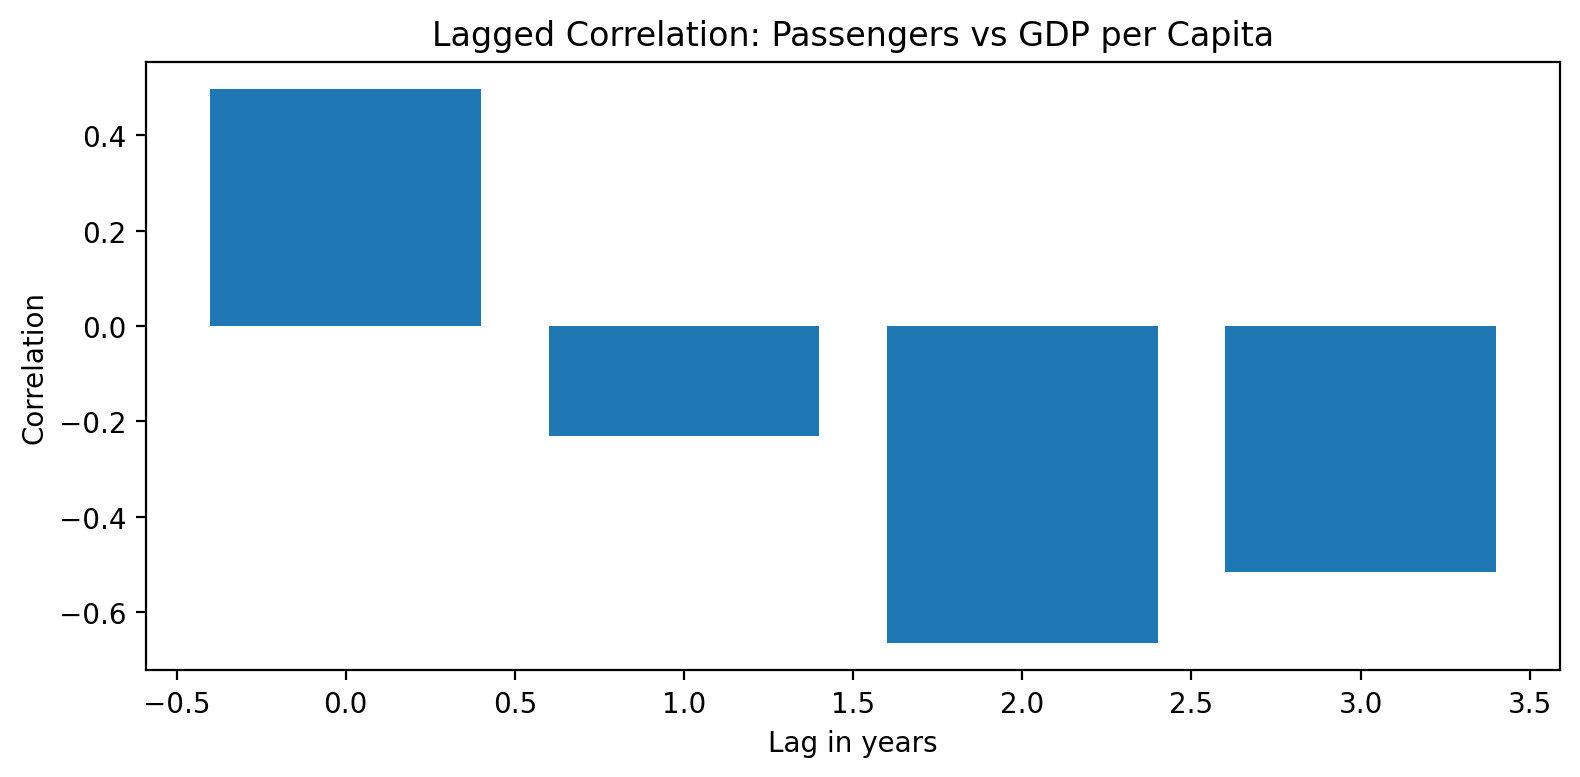

emirate_market_share.png


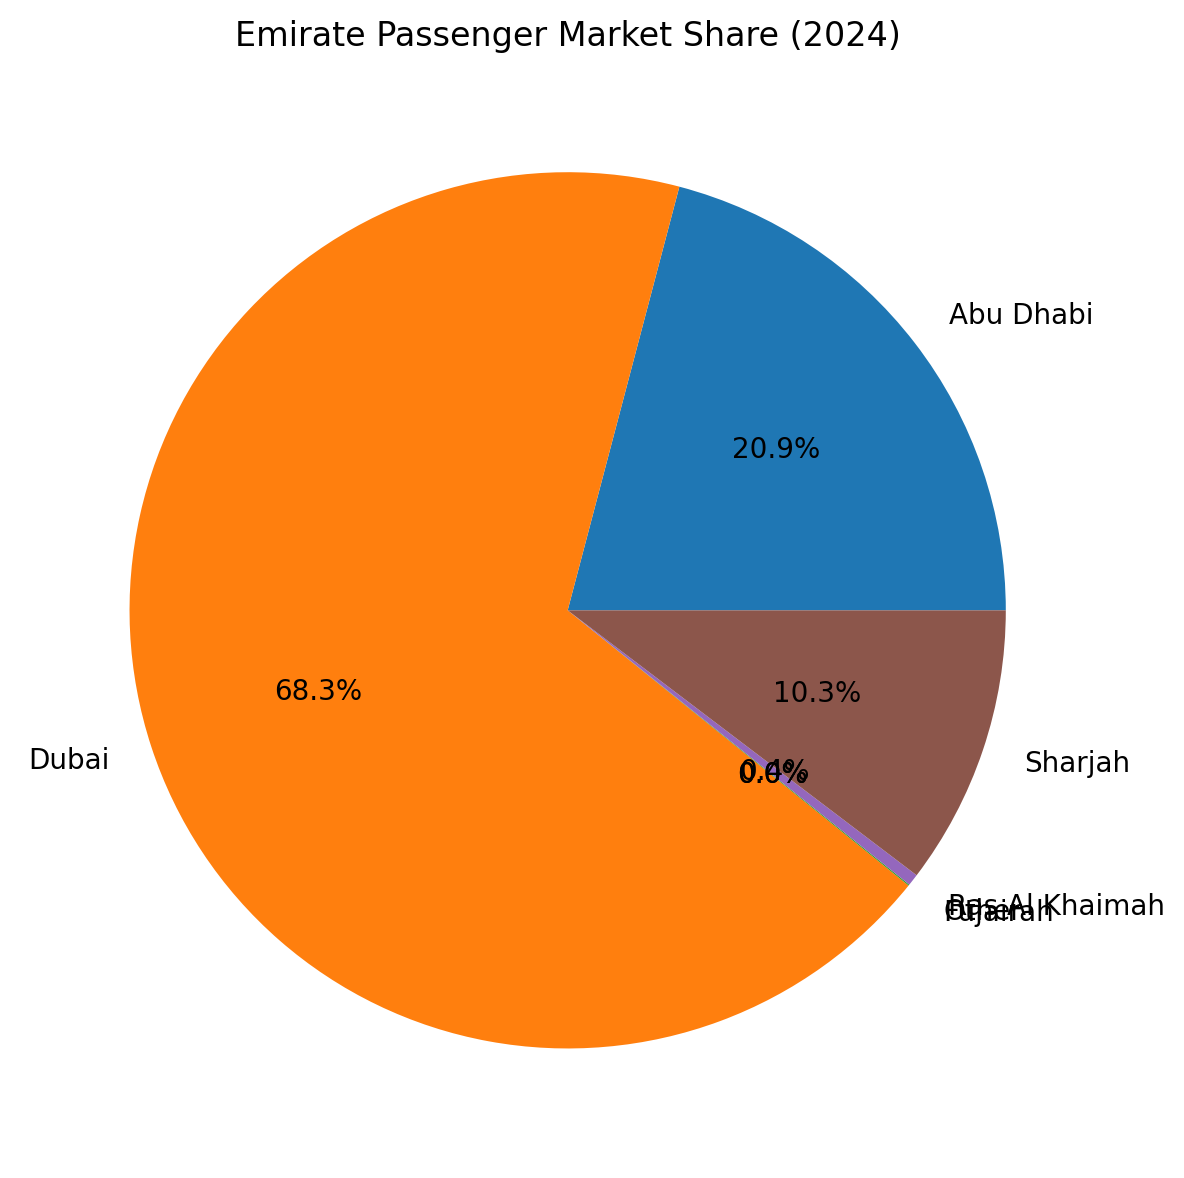

model_comparison.png


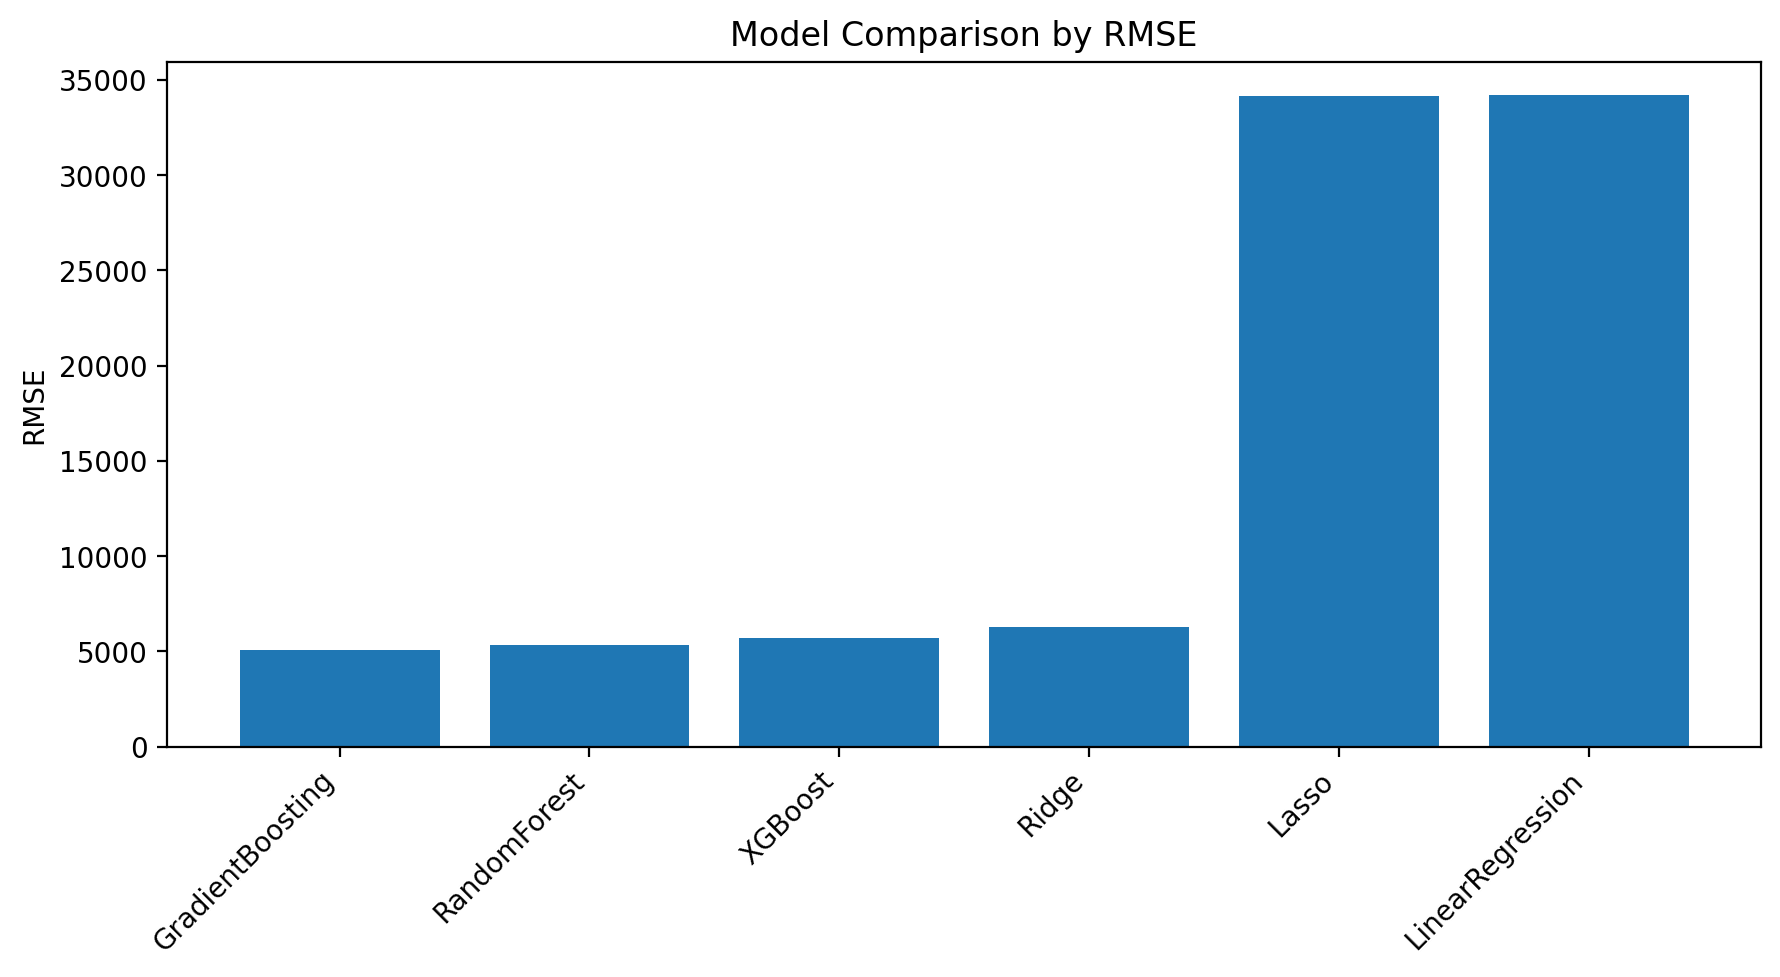

In [ ]:
from IPython.display import Image, display
for name in ['uae_passenger_vs_gdp.png', 'correlation_heatmap.png', 'lagged_correlations.png', 'emirate_market_share.png', 'model_comparison.png']:
    path = FIG_DIR / name
    if path.exists():
        print(name)
        display(Image(filename=str(path)))

## Download outputs from Colab

In [ ]:
from google.colab import files
import shutil
archive_path = '/content/airport_growth_outputs'
shutil.make_archive(archive_path, 'zip', OUTPUT_DIR)
files.download(archive_path + '.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>